# 22. LR·RBF-SVM의 Validation 튜닝

기존 266차원 특징과 원곡 단위 split으로 LR의 C 다섯 값, SVM의 C×gamma 16개 조합을 Train에서 학습했다. **Validation Track EER 최소 → AUC 최대 → 후보 순서**로 설정을 고르고, Segment·Track 임계값을 따로 저장했다. SVM의 `decision_function`은 확률이 아닌 margin이다. Test 평가는 23번에서 수행했다. 같은 Test의 과거 결과가 이미 공개된 이력은 남는다.

## 1. 환경과 입력 설정

`PROJECT_ROOT` 아래 기존 feature 파일만 읽는다. `results/model_tuning`과 `checkpoints/optimized`에 새 run의 산출물을 저장한다. 이 단계에서는 Test score를 계산하지 않는다. 함수 `evaluate_binary_predictions`는 모든 binary 모델이 재사용하는 공통 평가기다. `select_best_candidate`는 반올림 전 Validation Track 지표로 후보를 고른다.

In [1]:
# 실행 환경과 입력 파일의 출처를 기록하고 Train/Validation 전용 산출물 경로를 준비한다.
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import random
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.modeling_evaluation import evaluate_binary_predictions, select_best_candidate

SEED = 42
random.seed(SEED)  # Python 난수 고정
np.random.seed(SEED)  # NumPy 난수 고정
PROJECT_ROOT = Path.cwd().resolve()
FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
RESULT_DIR = PROJECT_ROOT / "results/model_tuning"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/optimized"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_ID = "classical_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
print("run_id:", RUN_ID)
print("feature file:", FEATURE_PATH)
print(
    "device: CPU; Python:",
    platform.python_version(),
    "scikit-learn:",
    sklearn.__version__,
)

run_id: classical_20260919T110356Z
feature file: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/features/handcrafted_features_10s.csv
device: CPU; Python: 3.13.9 scikit-learn: 1.7.2


실행 run_id는 `classical_20260919T110356Z`이다. CPU에서 Python 3.13.9와 scikit-learn 1.7.2를 사용했다.

모든 후보가 같은 실행 환경과 feature 파일을 사용했다.

seed=42만으로 다른 BLAS·운영체제에서 완전히 같은 수치를 보장할 수는 없다.

## 2. 데이터 무결성 및 학습 단위 검사

기존 split을 다시 만들지 않는다. 각 original_audio의 REAL/FAKE 파생 track과 segment가 한 split에 남아 있는지 확인한다. 중복 segment ID, track 내 label 불일치, label mapping, 결측·무한 feature, 266개 열 순서를 검사하고 오류가 있으면 중단한다. split별 original_audio/track/segment class 수와 manifest hash를 남긴다. Test의 **라벨·그룹 개수는 무결성 검사에만** 사용하며 Test feature나 모델 score는 선택 과정에 쓰지 않는다.

In [2]:
# 266개 feature와 ID를 manifest에 정렬하고 원곡 그룹 분리·class 분포를 확인한다.
REQUIRED = {
    "segment_id",
    "track_sample_id",
    "original_audio",
    "label",
    "label_id",
    "split",
}
df = pd.read_csv(FEATURE_PATH)
if not REQUIRED.issubset(df.columns):
    raise ValueError(f"필수 열 누락: {sorted(REQUIRED - set(df.columns))}")
if df["segment_id"].isna().any() or df["segment_id"].duplicated().any():
    raise ValueError("segment_id 결측 또는 중복")
if (
    df[["track_sample_id", "original_audio", "label", "label_id", "split"]]
    .isna()
    .any()
    .any()
):
    raise ValueError("group/label/split 결측")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
if set(df["split"].unique()) != {"train", "val", "test"}:
    raise ValueError("예상하지 않은 split 또는 누락된 split")
if not (
    (df["label"].eq("REAL") & df["label_id"].eq(0))
    | (df["label"].eq("FAKE") & df["label_id"].eq(1))
).all():
    raise ValueError("REAL=0, FAKE=1 mapping 불일치")
if df.groupby("original_audio")["split"].nunique().gt(1).any():
    raise ValueError("original_audio가 여러 split에 존재")
if (
    df.groupby("track_sample_id")[["label_id", "split", "original_audio"]]
    .nunique()
    .gt(1)
    .any()
    .any()
):
    raise ValueError("track 안의 label/split/original_audio 불일치")

# 기존 09번 노트북과 같은 접두사 및 정렬 규칙으로 266-D 순서를 고정한다.
FEATURE_COLUMNS = sorted(
    c
    for c in df.columns
    if c.startswith(
        ("mfcc_", "mfcc_delta_", "mfcc_delta2_", "spectral_", "rms_", "zcr_")
    )
)
if len(FEATURE_COLUMNS) != 266 or len(set(FEATURE_COLUMNS)) != 266:
    raise ValueError(f"예상한 266-D가 아님: {len(FEATURE_COLUMNS)}")
model_df = df.loc[df["split"].isin(["train", "val"])].copy()
model_df[FEATURE_COLUMNS] = model_df[FEATURE_COLUMNS].apply(
    pd.to_numeric, errors="raise"
)
if not np.isfinite(model_df[FEATURE_COLUMNS].to_numpy(dtype=np.float64)).all():
    raise ValueError("Train/Validation feature에 결측 또는 무한값")
train_df = model_df.loc[model_df["split"].eq("train")].copy().reset_index(drop=True)
val_df = model_df.loc[model_df["split"].eq("val")].copy().reset_index(drop=True)
if any(x["label_id"].nunique() != 2 for x in (train_df, val_df)):
    raise ValueError("Train/Validation에 두 class가 모두 있어야 함")
X_train, X_val = train_df[FEATURE_COLUMNS], val_df[FEATURE_COLUMNS]
y_train = train_df["label_id"].astype(int).to_numpy()
EXPECTED_VAL_IDS = tuple(val_df["segment_id"].astype(str))

# 원본 segment manifest와 feature 행의 ID/label/split이 정확히 같은지 확인한다.
MANIFEST_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
manifest_cols = [
    "segment_id",
    "track_sample_id",
    "original_audio",
    "label",
    "label_id",
    "split",
]
manifest_meta = pd.read_csv(MANIFEST_PATH, usecols=manifest_cols)
if manifest_meta["segment_id"].duplicated().any():
    raise ValueError("segment manifest의 segment_id 중복")
feature_meta = df[manifest_cols].sort_values("segment_id").reset_index(drop=True)
manifest_meta = manifest_meta.sort_values("segment_id").reset_index(drop=True)
if not feature_meta.equals(manifest_meta):
    raise ValueError(
        "feature와 원본 segment manifest의 ID/track/group/label/split 불일치"
    )
# 네 모델이 공유할 원본 manifest 파일의 실제 SHA-256을 저장한다.
MANIFEST_HASH = hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest()
class_counts = pd.concat(
    [
        df.groupby(["split", "label_id"]).size().rename("segments"),
        df.groupby(["split", "label_id"])["track_sample_id"].nunique().rename("tracks"),
        df.groupby(["split", "label_id"])["original_audio"]
        .nunique()
        .rename("original_audio"),
    ],
    axis=1,
).reset_index()
print(
    "feature count:",
    len(FEATURE_COLUMNS),
    "train/val segments:",
    len(train_df),
    len(val_df),
)
print("split manifest SHA-256:", MANIFEST_HASH)
display(class_counts)

feature count: 266 train/val segments: 6967 1538
split manifest SHA-256: 9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3


,split,label_id,segments,tracks,original_audio
0,test,0,135,45,45
1,test,1,1437,494,45
2,train,0,621,207,207
3,train,1,6346,2185,207
4,val,0,132,44,44
5,val,1,1406,483,44


266개 feature를 확인했다. Train은 6,967 segment(REAL 621, FAKE 6,346), Validation은 1,538 segment(REAL 132, FAKE 1,406)다. Test 1,572 segment의 ID·label·split은 원본 manifest와 대조했으며, **Test score는 계산하지 않았다**. 원본 segment manifest SHA-256은 `9023dcb21bef5d7163c63ea93258195e53c9fde3ecb7fee5920bf6ff94bbc2b3`이다. original_audio별 split 중복, segment ID 중복, track 내부 label 불일치가 없었다.

원본 manifest와 feature CSV의 segment ID, track, group, label, split이 모든 행에서 일치한다. 같은 Train/Validation segment 집합과 266개 열 순서를 모든 후보에 적용할 수 있다.

Train/Validation에서 FAKE 비율이 높다. 검사는 group 누수를 확인하지만 FMA REAL과 Echoes TTA FAKE 사이의 데이터 출처 차이를 제거하지는 않는다.

## 3. Baseline과 후보

LR Baseline은 `C=1`, `lbfgs`, L2, `max_iter=3000`, `class_weight="balanced"`이다. C 후보는 `[0.01,0.1,1,10,100]`이다. C가 작을수록 규제가 강하다.

RBF-SVM Baseline은 `C=1`, `gamma="scale"`, `class_weight="balanced"`이다. C 네 값과 gamma 네 값의 **16개 조합**을 비교한다. gamma가 클수록 각 표본의 영향 범위가 좁다. SVM은 `decision_function` margin을 사용하며 확률 보정은 하지 않았다.

두 모델의 scaler는 Train에만 맞춘다. 후보와 임계값은 Validation에서 고르고 Test에는 적용만 한다. 이 두 모델의 solver에는 CNN 같은 epoch·batch 설정이 없다.

In [3]:
# Baseline과 LR/SVM 탐색 후보를 학습 전에 선언해 Test 기반 변경을 막는다.
BASELINE_CONFIGS = {
    "LogisticRegression": {
        "C": 1.0,
        "solver": "lbfgs",
        "penalty": "l2",
        "class_weight": "balanced",
        "max_iter": 3000,
    },
    "RBF-SVM": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": "balanced",
        "probability": False,
    },
}
LR_C = [0.01, 0.1, 1.0, 10.0, 100.0]
SVM_C = [0.1, 1.0, 10.0, 100.0]
SVM_GAMMA = ["scale", 0.001, 0.01, 0.1]
CANDIDATES = {
    "LogisticRegression": [{"C": c} for c in LR_C],
    "RBF-SVM": [{"C": c, "gamma": g} for c in SVM_C for g in SVM_GAMMA],
}
# 실행 전에 baseline과 후보 순서를 저장해 사후 변경을 감지할 수 있게 한다.
predeclared = {
    "run_id": RUN_ID,
    "baseline": BASELINE_CONFIGS,
    "candidates": CANDIDATES,
    "selection": "Validation Track EER min, Track ROC-AUC max, candidate_order min",
}
(RESULT_DIR / "classical_predeclared_configs.json").write_text(
    json.dumps(predeclared, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("LR candidates:", len(CANDIDATES["LogisticRegression"]))
print("SVM candidates:", len(CANDIDATES["RBF-SVM"]))

LR candidates: 5
SVM candidates: 16


Logistic Regression 후보 5개와 RBF-SVM 후보 16개를 실행 전에 저장했다. LR Baseline `C=1.0`과 SVM Baseline `C=1.0, gamma="scale"`은 각각 후보 목록에 포함된다.

Baseline 후보를 별도로 다시 학습하지 않고 동일 후보의 Validation 평가를 재사용할 수 있다.

이 후보 목록은 제한된 탐색 범위이며 전체 가능한 설정의 절대 최적값을 보장하지 않는다.

## 4. 공통 학습·Validation 함수

`make_score_frame`은 원래 ID와 label을 score에 결합한다. `evaluate_binary_predictions`가 Segment/Track 집계, EER 보간, 별도 Validation 임계값, AP/REAL AP, 혼동행렬을 같은 규칙으로 계산한다. 후보마다 **동일한 Val segment ID**가 들어가도록 검사한다. 학습 함수는 수렴 경고를 숨기지 않고 결과표에 기록한다. LR의 FAKE 확률 열은 `classes_`로 확인한다.

In [4]:
# Train에서만 scaler를 학습하고 Validation score를 공통 Segment/Track 평가로 보낸다.
def make_score_frame(meta: pd.DataFrame, scores: np.ndarray) -> pd.DataFrame:
    """기존 식별자와 REAL=0/FAKE=1 label에 검증 score를 결합한다."""
    if len(meta) != len(scores):
        raise ValueError("score와 segment 행 개수가 다름")
    frame = (
        meta[["segment_id", "track_sample_id", "original_audio", "label_id"]]
        .rename(
            columns={
                "track_sample_id": "track_id",
                "original_audio": "original_audio_id",
                "label_id": "label",
            }
        )
        .copy()
    )
    frame["score"] = np.asarray(scores, dtype=float)
    if not np.isfinite(frame["score"]).all():
        raise ValueError("score 결측 또는 무한값")
    if tuple(frame["segment_id"].astype(str)) != EXPECTED_VAL_IDS:
        raise ValueError("후보별 Validation segment 집합/순서 불일치")
    return frame


def build_pipeline(model_name: str, config: dict) -> Pipeline:
    """Train-only StandardScaler와 고정 분류기를 하나의 checkpoint로 묶는다."""
    if model_name == "LogisticRegression":
        classifier = LogisticRegression(
            C=config["C"],
            solver="lbfgs",
            penalty="l2",
            # 클래스별 표본 수가 달라 손실에 기여하는 비중을 조정한다.
            class_weight="balanced",
            max_iter=3000,
            random_state=SEED,
        )
    elif model_name == "RBF-SVM":
        classifier = SVC(
            kernel="rbf",
            C=config["C"],
            gamma=config["gamma"],
            class_weight="balanced",
            probability=False,
            cache_size=2048,
            random_state=SEED,
        )
    else:
        raise ValueError(model_name)
    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    return Pipeline([("scaler", StandardScaler()), ("classifier", classifier)])


def score_candidate(pipeline: Pipeline, model_name: str, X: pd.DataFrame) -> np.ndarray:
    """FAKE=1 방향의 LR 확률 또는 SVM margin을 계산한다."""
    classifier = pipeline.named_steps["classifier"]
    if not np.array_equal(classifier.classes_, np.array([0, 1])):
        raise ValueError(f"class 순서 불일치: {classifier.classes_}")
    if model_name == "LogisticRegression":
        fake_col = int(np.flatnonzero(classifier.classes_ == 1)[0])
        # `predict_proba`로 각 클래스의 예측 확률을 얻는다.
        return pipeline.predict_proba(X)[:, fake_col]
    return pipeline.decision_function(X)


def run_candidate(model_name: str, config: dict, order: int):
    """한 후보를 Train으로 fit하고 동일 Validation 집합에서만 평가한다."""
    pipeline = build_pipeline(model_name, config)
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always", ConvergenceWarning)
        # Pipeline은 scaler를 Train에 fit한 다음 같은 Train segment로 분류기를 학습한다.
        pipeline.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start
    warning_messages = [str(w.message) for w in captured]
    for message in warning_messages:
        print(f"{model_name} candidate {order} warning: {message}")
    start = time.perf_counter()
    scores = score_candidate(pipeline, model_name, X_val)
    inference_seconds = time.perf_counter() - start
    frame = make_score_frame(val_df, scores)
    evaluation = evaluate_binary_predictions(frame, thresholds=None)
    row = {
        "run_id": RUN_ID,
        "model": model_name,
        "candidate_order": order,
        "C": config["C"],
        "gamma": config.get("gamma"),
        "val_segment_auc": evaluation["segment"]["roc_auc"],
        "val_segment_eer": evaluation["segment"]["eer"],
        "track_roc_auc": evaluation["track"]["roc_auc"],
        "track_eer": evaluation["track"]["eer"],
        "val_track_macro_f1": evaluation["track"]["macro_f1"],
        "val_segment_threshold": evaluation["thresholds"]["segment"],
        "val_track_threshold": evaluation["thresholds"]["track"],
        "train_seconds": train_seconds,
        "val_inference_seconds": inference_seconds,
        "train_segments": len(X_train),
        "val_segments": len(X_val),
        "warnings": json.dumps(warning_messages, ensure_ascii=False),
    }
    return row, pipeline, evaluation, frame

공통 학습·평가 함수를 정의했다. 수치 결과는 다음 후보 실행 셀에 기록된다.

모든 후보에 동일한 `evaluate_binary_predictions`와 후보 선택 규칙을 적용한다.

SVM margin과 LR 확률의 절대 크기는 비교할 수 없다. score 평균은 각 모델 내부의 track 집계에만 쓴다.

## 5. Logistic Regression 탐색

Baseline C=1.0은 후보 루프에서 한 번만 학습한다. 각 C의 Validation Segment/Track AUC와 EER, Track Macro-F1을 기록한다. Track EER를 우선하고 동률이면 Track AUC, 다시 동률이면 사전 후보 순서로 선택한다. 현재 최고 후보만 optimized checkpoint에 저장하여 모든 모델을 메모리에 보관하지 않는다. 수렴 경고는 CSV와 화면에 남긴다.

In [5]:
# LR의 C 후보를 동일한 Train/Validation으로 학습한 뒤 Validation Track EER로 고른다.
def run_search(model_name: str, candidates: list[dict], stem: str):
    """사전 고정 후보를 Train/Validation으로 비교하고 baseline과 best를 보존한다."""
    rows = []
    baseline_payload = None
    best_payload = None
    best_path = CHECKPOINT_DIR / f"{stem}_best.joblib"
    baseline_path = CHECKPOINT_DIR / f"{stem}_baseline.joblib"
    for order, config in enumerate(candidates):
        row, pipeline, evaluation, frame = run_candidate(model_name, config, order)
        rows.append(row)
        print(
            model_name,
            order,
            config,
            "Track EER:",
            row["track_eer"],
            "Track AUC:",
            row["track_roc_auc"],
        )
        baseline_match = (
            config == {"C": 1.0}
            if model_name == "LogisticRegression"
            else config == {"C": 1.0, "gamma": "scale"}
        )
        if baseline_match:
            joblib.dump(pipeline, baseline_path)
            baseline_payload = (row.copy(), evaluation, frame.copy())
        selected = select_best_candidate(rows)
        if selected["candidate_order"] == order:
            joblib.dump(pipeline, best_path)
            best_payload = (row.copy(), evaluation, frame.copy())
    if baseline_payload is None or best_payload is None:
        raise RuntimeError("baseline 또는 best 후보 누락")
    table = pd.DataFrame(rows)
    table.to_csv(RESULT_DIR / f"{stem}_tuning.csv", index=False, encoding="utf-8-sig")
    return {
        "table": table,
        "baseline": baseline_payload,
        "best": best_payload,
        "baseline_path": baseline_path,
        "best_path": best_path,
    }


lr_run = run_search("LogisticRegression", CANDIDATES["LogisticRegression"], "logistic")
display(
    lr_run["table"][
        [
            "C",
            "val_segment_auc",
            "val_segment_eer",
            "track_roc_auc",
            "track_eer",
            "val_track_macro_f1",
            "train_seconds",
            "warnings",
        ]
    ]
)
print("Selected C:", lr_run["best"][0]["C"])

LogisticRegression 0 {'C': 0.01} Track EER: 0.10351966873706009 Track AUC: 0.9606625258799171


LogisticRegression 1 {'C': 0.1} Track EER: 0.11363636363636363 Track AUC: 0.9636269527573874


LogisticRegression 2 {'C': 1.0} Track EER: 0.11363636363636363 Track AUC: 0.9620741577263316


LogisticRegression 3 {'C': 10.0} Track EER: 0.11363636363636363 Track AUC: 0.9596273291925466


LogisticRegression 4 {'C': 100.0} Track EER: 0.11363636363636363 Track AUC: 0.959486166007905


,C,val_segment_auc,val_segment_eer,track_roc_auc,track_eer,val_track_macro_f1,train_seconds,warnings
0,0.01,0.912265,0.174253,0.960663,0.103520,0.763374,0.052004,[]
1,0.10,0.915282,0.166667,0.963627,0.113636,0.749858,0.166313,[]
2,1.00,0.914382,0.158606,0.962074,0.113636,0.749858,0.181509,[]
3,10.00,0.913175,0.159091,0.959627,0.113636,0.749858,0.269612,[]
4,100.00,0.912900,0.159091,0.959486,0.113636,0.749858,0.201671,[]


Selected C: 0.01


5개 C를 모두 학습했다. Validation Track EER는 Baseline `C=1.0`에서 **0.1136**, 선택된 `C=0.01`에서 **0.1035**였다. Track ROC-AUC는 각각 0.9621과 0.9607, Track Macro-F1은 0.7499와 0.7634였다. Segment EER는 0.1586에서 0.1743으로 높아졌다. 학습 수렴 경고는 기록되지 않았다.

사전 선택 기준인 Track EER가 가장 낮아 `C=0.01`을 선택했다. Track 단위의 EER와 Macro-F1은 개선됐지만 ROC-AUC는 조금 낮아졌고 Segment EER도 나빠졌다. 작은 C의 더 강한 정규화가 이 Validation Track 기준에서는 유리했다는 범위에서 해석한다.

Validation에서 선택한 설정이 다른 데이터에서도 우수하다는 보장은 없다. 특히 Segment와 Track 지표의 방향이 달라 한 수치만으로 전반적 개선을 단정할 수 없다. Test는 아직 평가하지 않았다.

## 6. RBF-SVM 탐색

16개 조합을 사전 순서로 독립 학습한다. LR과 동일한 feature 열, Train segment와 Train-only StandardScaler를 쓴다. 각 Pipeline에 scaler를 함께 저장한다. `decision_function` margin으로 검증 score를 만들고, Track EER/ROC-AUC 규칙으로 한 조합을 선택한다. 높은 C나 gamma에서 시간이 오래 걸릴 수 있으므로 각 후보 학습·추론 시간을 기록한다.

In [6]:
# RBF-SVM C×gamma 후보를 학습하고 decision margin으로 Validation을 평가한다.
svm_run = run_search("RBF-SVM", CANDIDATES["RBF-SVM"], "svm")
display(
    svm_run["table"][
        [
            "C",
            "gamma",
            "val_segment_auc",
            "val_segment_eer",
            "track_roc_auc",
            "track_eer",
            "val_track_macro_f1",
            "train_seconds",
            "warnings",
        ]
    ]
)
print("Selected C/gamma:", (svm_run["best"][0]["C"], svm_run["best"][0]["gamma"]))
# 두 Pipeline은 같은 Train 행과 feature 순서로 scaler를 fit해야 한다.
lr_scaler = joblib.load(lr_run["best_path"]).named_steps["scaler"]
svm_scaler = joblib.load(svm_run["best_path"]).named_steps["scaler"]
if not np.array_equal(lr_scaler.mean_, svm_scaler.mean_):
    raise ValueError("LR/SVM Train-only scaler 통계 불일치")
if (
    list(lr_scaler.feature_names_in_) != FEATURE_COLUMNS
    or list(svm_scaler.feature_names_in_) != FEATURE_COLUMNS
):
    raise ValueError("저장된 Pipeline의 266-D feature 순서 불일치")

RBF-SVM 0 {'C': 0.1, 'gamma': 'scale'} Track EER: 0.12008281573498969 Track AUC: 0.9531338226990401


RBF-SVM 1 {'C': 0.1, 'gamma': 0.001} Track EER: 0.11363636363636363 Track AUC: 0.9464520986260117


RBF-SVM 2 {'C': 0.1, 'gamma': 0.01} Track EER: 0.25 Track AUC: 0.8924807076980991


RBF-SVM 3 {'C': 0.1, 'gamma': 0.1} Track EER: 0.1590909090909091 Track AUC: 0.8960333145115753


RBF-SVM 4 {'C': 1.0, 'gamma': 'scale'} Track EER: 0.07867494824016563 Track AUC: 0.9753434970826276


...

RBF-SVM 13 {'C': 100.0, 'gamma': 0.001} Track EER: 0.06818181818181818 Track AUC: 0.9720496894409938


RBF-SVM 14 {'C': 100.0, 'gamma': 0.01} Track EER: 0.082815734989648 Track AUC: 0.9808959156785244


RBF-SVM 15 {'C': 100.0, 'gamma': 0.1} Track EER: 0.1590909090909091 Track AUC: 0.8965744400527009


,C,gamma,val_segment_auc,val_segment_eer,track_roc_auc,track_eer,val_track_macro_f1,train_seconds,warnings
0,0.1,scale,0.901348,0.189394,0.953134,0.120083,0.742094,1.444182,[]
1,0.1,0.001,0.895911,0.181818,0.946452,0.113636,0.749858,1.399233,[]
2,0.1,0.01,0.858006,0.242424,0.892481,0.250000,0.589564,1.647017,[]
3,0.1,0.1,0.865140,0.196970,0.896033,0.159091,0.687302,1.954541,[]
4,1.0,scale,0.933521,0.143939,0.975343,0.078675,0.811314,0.752720,[]
5,1.0,0.001,0.918062,0.174242,0.965321,0.090909,0.786582,0.892144,[]
6,1.0,0.01,0.929507,0.159091,0.974214,0.091097,0.786582,1.157269,[]
7,1.0,0.1,0.866400,0.196970,0.896692,0.159091,0.687302,2.063290,[]
8,10.0,scale,0.942885,0.136364,0.981319,0.070393,0.824752,0.647305,[]
9,10.0,0.001,0.932163,0.141536,0.970497,0.060041,0.842628,0.615319,[]


Selected C/gamma: (10.0, 0.001)


16개 C/gamma 조합을 모두 학습했다. Baseline `C=1.0, gamma="scale"`의 Validation Track EER는 **0.0787**, 선택된 `C=10.0, gamma=0.001`은 **0.0600**이었다. Track ROC-AUC는 각각 0.9753과 0.9705, Track Macro-F1은 0.8113과 0.8426이었다. Segment EER는 0.1439에서 0.1415로 낮아졌다. 수렴 경고는 기록되지 않았다.

사전 선택 기준인 Track EER에 따라 `C=10.0, gamma=0.001`을 선택했다. Track EER와 Macro-F1은 개선됐지만 Track ROC-AUC는 낮아졌다. 탐색 범위 내 두 지표가 같은 방향으로 움직이지 않았다.

16개 조합은 전체 parameter space를 대표하지 않는다. 모델별 계산 예산도 동일하지 않다. SVM score는 margin이며 확률로 해석하지 않는다. Test는 아직 평가하지 않았다.

## 7. 선택 결과 동결 및 저장

Baseline과 Optimized 각각에 대해 Segment/Track Validation 임계값과 raw score를 저장한다. 같은 설정이면 후보 학습과 Validation score를 재사용한다. 후속 최종 평가에서는 이 Train 학습 checkpoint를 그대로 사용하고 Train+Validation 재학습은 하지 않는다. Test에서 임계값을 새로 정하지 않는다. CSV에는 split, level, model, run_id, threshold와 표본 수를 포함한다.

In [7]:
# Baseline/Optimized checkpoint, 선택 설정, 임계값과 원점수를 최종 Test 전에 동결한다.
def jsonable_config(model_name: str, row: dict, path: Path) -> dict:
    """선택한 학습 설정과 checkpoint 경로를 JSON으로 직렬화한다."""
    params = {"C": float(row["C"])}
    if model_name == "RBF-SVM":
        params["gamma"] = row["gamma"]
    full_params = {**BASELINE_CONFIGS[model_name], **params}
    return {
        "params": full_params,
        "checkpoint": str(path),
        "checkpoint_sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        "candidate_order": int(row["candidate_order"]),
        "train_segments": int(row["train_segments"]),
        "val_segments": int(row["val_segments"]),
    }


runs = {"LogisticRegression": lr_run, "RBF-SVM": svm_run}
baseline_configs = {}
best_configs = {}
thresholds = {}
metric_rows = []
score_files = []
for model_name, run in runs.items():
    baseline_row, _, _ = run["baseline"]
    best_row, _, _ = run["best"]
    baseline_configs[model_name] = jsonable_config(
        model_name, baseline_row, run["baseline_path"]
    )
    best_configs[model_name] = jsonable_config(model_name, best_row, run["best_path"])
    thresholds[model_name] = {}
    for variant, payload in (("baseline", run["baseline"]), ("optimized", run["best"])):
        row, evaluation, frame = payload
        thresholds[model_name][variant] = {
            "segment": float(evaluation["thresholds"]["segment"]),
            "track": float(evaluation["thresholds"]["track"]),
        }
        for level in ("segment", "track"):
            metric_rows.append(
                {
                    "run_id": RUN_ID,
                    "model": model_name,
                    "variant": variant,
                    "split": "val",
                    "level": level,
                    "threshold": thresholds[model_name][variant][level],
                    "n_samples": (
                        len(frame)
                        if level == "segment"
                        else len(evaluation["track_scores"])
                    ),
                    **evaluation[level],
                }
            )
            raw = (
                frame.copy()
                if level == "segment"
                else evaluation["track_scores"].copy()
            )
            raw["run_id"] = RUN_ID
            raw["model"] = model_name
            raw["variant"] = variant
            # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
            raw["split"] = "val"
            raw["threshold"] = thresholds[model_name][variant][level]
            raw["prediction"] = (raw["score"] >= raw["threshold"]).astype(int)
            score_path = (
                RESULT_DIR / f"{RUN_ID}_{model_name}_{variant}_{level}_scores.csv"
            )
            raw.to_csv(score_path, index=False, encoding="utf-8-sig")
            score_files.append(str(score_path))

validation_metrics = pd.DataFrame(metric_rows)
validation_metrics.to_csv(
    RESULT_DIR / "classical_validation_metrics.csv", index=False, encoding="utf-8-sig"
)
for filename, content in (
    ("classical_baseline_configs.json", baseline_configs),
    ("classical_best_configs.json", best_configs),
    ("classical_validation_thresholds.json", thresholds),
):
    (RESULT_DIR / filename).write_text(
        json.dumps(
            {
                "run_id": RUN_ID,
                "split_manifest_sha256": MANIFEST_HASH,
                "models": content,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
metadata = {
    "run_id": RUN_ID,
    "split_manifest_sha256": MANIFEST_HASH,
    "feature_columns": FEATURE_COLUMNS,
    "seed": SEED,
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "device": "CPU",
    "candidate_counts": {k: len(v) for k, v in CANDIDATES.items()},
    "score_files": score_files,
    "test_evaluated": False,
}
(RESULT_DIR / "classical_run_metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(
    validation_metrics[
        [
            "model",
            "variant",
            "level",
            "n_samples",
            "real_prevalence",
            "fake_prevalence",
            "roc_auc",
            "ap_fake",
            "ap_real",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "hter",
            "threshold",
        ]
    ]
)
print(
    "Saved checkpoints, Validation scores, metrics, configs and thresholds for", RUN_ID
)

,model,variant,level,n_samples,real_prevalence,fake_prevalence,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter,threshold
0,LogisticRegression,baseline,segment,1538,0.085826,0.914174,0.914382,0.989222,0.607080,0.158606,0.841152,0.691454,0.159091,0.158606,0.158848,0.666339
1,LogisticRegression,baseline,track,527,0.083491,0.916509,0.962074,0.996056,0.830234,0.113636,0.886246,0.749858,0.113636,0.113872,0.113754,0.634330
2,LogisticRegression,optimized,segment,1538,0.085826,0.914174,0.912265,0.989964,0.643927,0.174253,0.825752,0.672542,0.174242,0.174253,0.174248,0.567690
3,LogisticRegression,optimized,track,527,0.083491,0.916509,0.960663,0.995556,0.806865,0.103520,0.891422,0.763374,0.113636,0.103520,0.108578,0.563456
4,RBF-SVM,baseline,segment,1538,0.085826,0.914174,0.933521,0.992822,0.706055,0.143939,0.856195,0.710765,0.143939,0.143670,0.143805,0.519650
5,RBF-SVM,baseline,track,527,0.083491,0.916509,0.975343,0.997409,0.864695,0.078675,0.926572,0.811314,0.068182,0.078675,0.073428,0.592604
6,RBF-SVM,optimized,segment,1538,0.085826,0.914174,0.932163,0.991489,0.736296,0.141536,0.857262,0.713091,0.143939,0.141536,0.142738,0.584756
7,RBF-SVM,optimized,track,527,0.083491,0.916509,0.970497,0.995176,0.887871,0.060041,0.935888,0.842628,0.068182,0.060041,0.064112,0.661505


Saved checkpoints, Validation scores, metrics, configs and thresholds for classical_20260919T110356Z


Validation **Track** 결과(각 설정의 Validation Track 임계값 적용)는 다음과 같다.

| 모델 | 설정 | ROC-AUC | FAKE AP | REAL AP | EER | Balanced Accuracy | Macro-F1 | REAL FPR | FAKE Miss Rate |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| LR | Baseline C=1 | 0.9621 | 0.9961 | 0.8302 | 0.1136 | 0.8862 | 0.7499 | 0.1136 | 0.1139 |
| LR | Optimized C=0.01 | 0.9607 | 0.9956 | 0.8069 | 0.1035 | 0.8914 | 0.7634 | 0.1136 | 0.1035 |
| SVM | Baseline C=1, gamma=scale | 0.9753 | 0.9974 | 0.8647 | 0.0787 | 0.9266 | 0.8113 | 0.0682 | 0.0787 |
| SVM | Optimized C=10, gamma=0.001 | 0.9705 | 0.9952 | 0.8879 | 0.0600 | 0.9359 | 0.8426 | 0.0682 | 0.0600 |

Validation Segment는 REAL 132/FAKE 1,406, Track은 REAL 44/FAKE 483이다. 임계값, raw score, Pipeline checkpoint와 SHA-256을 결과 파일에 저장했다.

두 모델 모두 선택 기준인 Validation Track EER가 Baseline보다 낮았다. SVM 선택 설정의 Track EER가 LR보다 낮지만 두 모델의 score 척도는 서로 다르다. FAKE AP가 매우 높은 결과는 약 91.65%인 Track FAKE 비율과 함께 읽어야 한다.

위 표는 **Validation 결과**이며 최종 Test 성능이 아니다. Balanced Accuracy, Macro-F1, REAL FPR, FAKE Miss Rate는 각자의 Validation 임계값에 의존한다. 이 데이터의 출처·장르·코덱 차이 때문에 일반적인 AI 음악 탐지 성능으로 확대 해석할 수 없다.

## 실행 상태와 최종 Test 연결

이 노트북의 **Train/Validation 실행은 완료**되었다(`classical_20260919T110356Z`). Logistic Regression 5개와 RBF-SVM 16개 후보를 모두 평가했고, `classical_validation_metrics.csv`, 튜닝 CSV, raw Validation score, checkpoint 및 설정·임계값 JSON을 저장했다. Test score는 계산하지 않았다.

최종 단계는 CNN·MERT 설정 및 threshold까지 모두 고정된 뒤 시작한다. 같은 기존 Test segment 집합을 사용해 Baseline과 Optimized를 평가하고, Test EER는 분리력 통계량으로만 계산한다. Test Balanced Accuracy, Macro-F1, REAL FPR, FAKE Miss Rate와 HTER에는 **대응하는 Validation threshold**를 적용한다. Baseline과 Optimized 설정이 같으면 저장 예측을 재사용한다. 네 모델 간 score의 절대 크기는 비교하지 않는다. FMA와 Echoes TTA의 출처·장르·코덱 차이가 반영될 수 있어 높은 수치를 보편적 AI 음악 탐지 능력으로 단정하지 않는다.

## 8. Logistic Regression — 저장된 Validation 후보와 Baseline 비교

C 5개의 저장된 결과를 읽어 Baseline과 선택 모델을 비교한다. 모든 값은 Validation 곡 단위이며, Test 결과가 아니다.

C,track_roc_auc,track_eer,val_track_macro_f1
0.01,0.9607,0.1035,0.7634
0.10,0.9636,0.1136,0.7499
1.00,0.9621,0.1136,0.7499
10.00,0.9596,0.1136,0.7499
100.00,0.9595,0.1136,0.7499


설정,C,Track ROC-AUC ↑,Track EER ↓,Track Macro-F1 ↑
Baseline,1.00,0.9621,0.1136,0.7499
Selected,0.01,0.9607,0.1035,0.7634


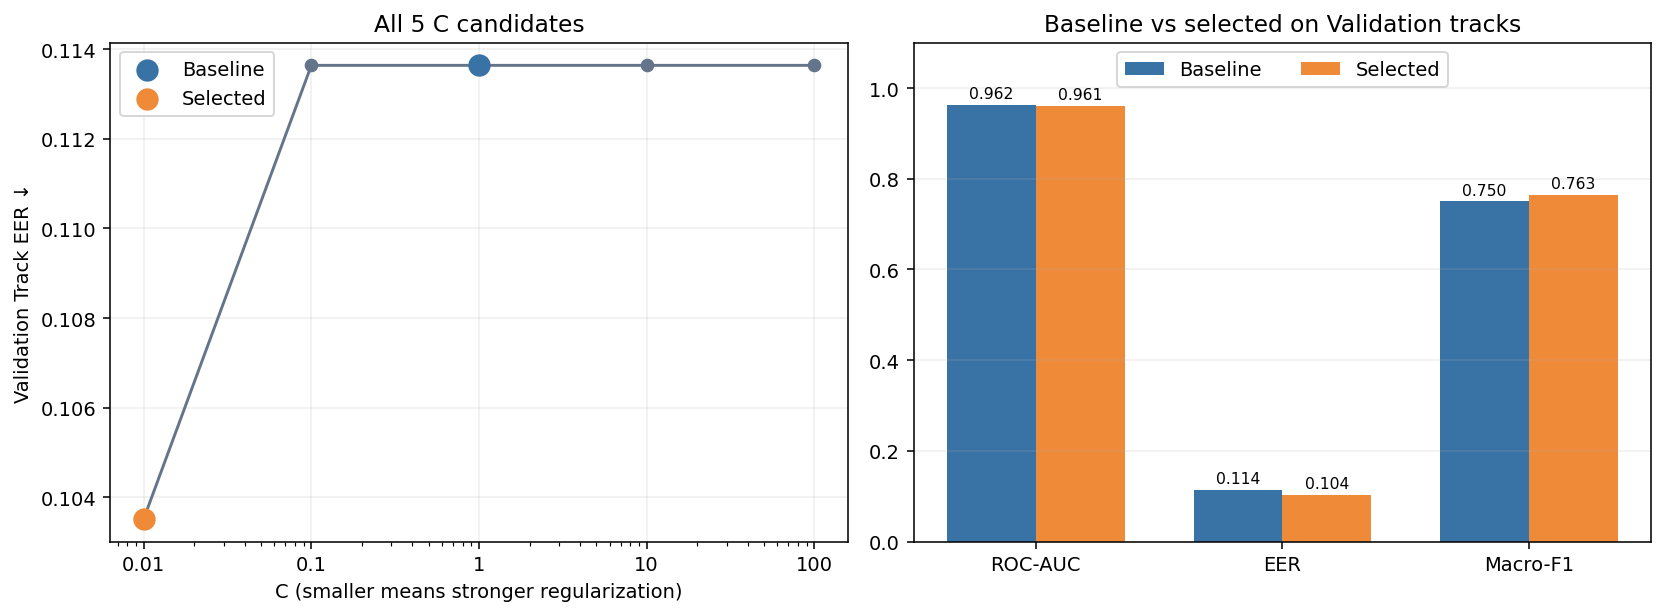

Saved: results/model_tuning/validation_comparisons/logistic_validation_comparison.png


In [8]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
model_name = 'LogisticRegression'
candidates = pd.read_csv(result_dir / 'logistic_tuning.csv').sort_values("candidate_order")
baseline_config = json.loads((result_dir / "classical_baseline_configs.json").read_text())
selected_config = json.loads((result_dir / "classical_best_configs.json").read_text())
assert candidates["run_id"].nunique() == 1
assert candidates["run_id"].iloc[0] == baseline_config["run_id"] == selected_config["run_id"]
baseline_order = baseline_config["models"][model_name]["candidate_order"]
selected_order = selected_config["models"][model_name]["candidate_order"]
baseline = candidates.loc[candidates["candidate_order"] == baseline_order].iloc[0]
selected = candidates.loc[candidates["candidate_order"] == selected_order].iloc[0]
assert np.isclose(baseline["C"], baseline_config["models"][model_name]["params"]["C"])
assert np.isclose(selected["C"], selected_config["models"][model_name]["params"]["C"])
assert len(candidates) == 5
# 다섯 C 후보를 전부 보여 주고, 선택 기준인 Track EER를 그린다.
display(candidates[["C", "track_roc_auc", "track_eer", "val_track_macro_f1"]].round(4))
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "C": [baseline["C"], selected["C"]],
    "Track ROC-AUC ↑": [baseline["track_roc_auc"], selected["track_roc_auc"]],
    "Track EER ↓": [baseline["track_eer"], selected["track_eer"]],
    "Track Macro-F1 ↑": [baseline["val_track_macro_f1"], selected["val_track_macro_f1"]],
})
display(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(candidates["C"], candidates["track_eer"], "o-", color="#64748b")
axes[0].scatter([baseline["C"]], [baseline["track_eer"]], s=110, label="Baseline", color="#3973a6", zorder=3)
axes[0].scatter([selected["C"]], [selected["track_eer"]], s=110, label="Selected", color="#ef8b38", zorder=3)
axes[0].set_xscale("log")
axes[0].set_xticks(candidates["C"], [f"{c:g}" for c in candidates["C"]])
axes[0].set_xlabel("C (smaller means stronger regularization)")
axes[0].set_ylabel("Validation Track EER ↓")
axes[0].set_title("All 5 C candidates")
axes[0].legend()
axes[0].grid(alpha=0.2)

figure_path = figure_dir / 'logistic_validation_comparison.png'
baseline = baseline.rename({"val_track_macro_f1": "track_macro_f1"})
selected = selected.rename({"val_track_macro_f1": "track_macro_f1"})
# 같은 Validation Track 지표를 두 설정에서 나란히 비교한다.
metric_names = ["ROC-AUC", "EER", "Macro-F1"]
baseline_values = [baseline["track_roc_auc"], baseline["track_eer"], baseline["track_macro_f1"]]
selected_values = [selected["track_roc_auc"], selected["track_eer"], selected["track_macro_f1"]]
positions = np.arange(len(metric_names))
baseline_bars = axes[1].bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
selected_bars = axes[1].bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
axes[1].bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].set_xticks(positions, metric_names)
axes[1].set_ylim(0, 1.10)
axes[1].set_title("Baseline vs selected on Validation tracks")
axes[1].legend(loc="upper center", ncol=2)
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))


## 9. RBF-SVM — 저장된 Validation 후보와 Baseline 비교

C×gamma 16개 후보의 EER와 Baseline·선택 모델을 함께 본다. 저장된 Validation 결과만 사용한다.

설정,C,gamma,Track ROC-AUC ↑,Track EER ↓,Track Macro-F1 ↑
Baseline,1.0,scale,0.9753,0.0787,0.8113
Selected,10.0,0.001,0.9705,0.0600,0.8426


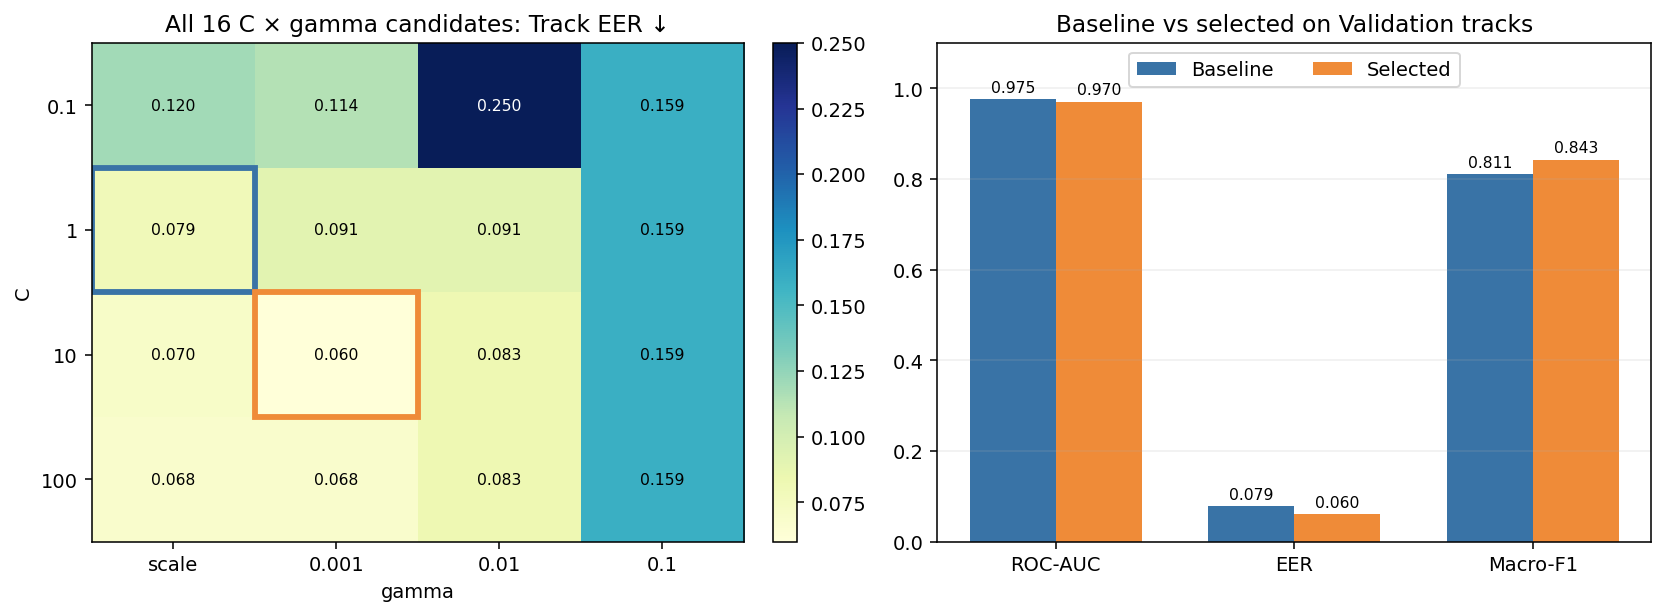

Saved: results/model_tuning/validation_comparisons/svm_validation_comparison.png


In [9]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
model_name = 'RBF-SVM'
candidates = pd.read_csv(result_dir / 'svm_tuning.csv').sort_values("candidate_order")
baseline_config = json.loads((result_dir / "classical_baseline_configs.json").read_text())
selected_config = json.loads((result_dir / "classical_best_configs.json").read_text())
assert candidates["run_id"].nunique() == 1
assert candidates["run_id"].iloc[0] == baseline_config["run_id"] == selected_config["run_id"]
baseline_order = baseline_config["models"][model_name]["candidate_order"]
selected_order = selected_config["models"][model_name]["candidate_order"]
baseline = candidates.loc[candidates["candidate_order"] == baseline_order].iloc[0]
selected = candidates.loc[candidates["candidate_order"] == selected_order].iloc[0]
assert np.isclose(baseline["C"], baseline_config["models"][model_name]["params"]["C"])
assert np.isclose(selected["C"], selected_config["models"][model_name]["params"]["C"])
assert len(candidates) == 16
assert str(baseline["gamma"]) == str(baseline_config["models"][model_name]["params"]["gamma"])
assert str(selected["gamma"]) == str(selected_config["models"][model_name]["params"]["gamma"])
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "C": [baseline["C"], selected["C"]],
    "gamma": [baseline["gamma"], selected["gamma"]],
    "Track ROC-AUC ↑": [baseline["track_roc_auc"], selected["track_roc_auc"]],
    "Track EER ↓": [baseline["track_eer"], selected["track_eer"]],
    "Track Macro-F1 ↑": [baseline["val_track_macro_f1"], selected["val_track_macro_f1"]],
})
display(summary.round(4))

# 16개 C×gamma 조합을 빠짐없이 같은 색 눈금에 표시한다.
c_values = sorted(candidates["C"].unique())
gamma_values = ["scale", "0.001", "0.01", "0.1"]
grid = candidates.pivot(index="C", columns="gamma", values="track_eer").loc[c_values, gamma_values]
assert grid.notna().all().all()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image = axes[0].imshow(grid.to_numpy(), cmap="YlGnBu", aspect="auto")
axes[0].set_xticks(range(len(gamma_values)), gamma_values)
axes[0].set_yticks(range(len(c_values)), [f"{c:g}" for c in c_values])
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("C")
axes[0].set_title("All 16 C × gamma candidates: Track EER ↓")
for row in range(len(c_values)):
    for col in range(len(gamma_values)):
        value = grid.iloc[row, col]
        axes[0].text(col, row, f"{value:.3f}", ha="center", va="center", fontsize=8, color="white" if value > 0.18 else "black")
from matplotlib.patches import Rectangle
for item, color in [(baseline, "#3973a6"), (selected, "#ef8b38")]:
    row = c_values.index(item["C"])
    col = gamma_values.index(str(item["gamma"]))
    axes[0].add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=3))
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

figure_path = figure_dir / 'svm_validation_comparison.png'
baseline = baseline.rename({"val_track_macro_f1": "track_macro_f1"})
selected = selected.rename({"val_track_macro_f1": "track_macro_f1"})
# 같은 Validation Track 지표를 두 설정에서 나란히 비교한다.
metric_names = ["ROC-AUC", "EER", "Macro-F1"]
baseline_values = [baseline["track_roc_auc"], baseline["track_eer"], baseline["track_macro_f1"]]
selected_values = [selected["track_roc_auc"], selected["track_eer"], selected["track_macro_f1"]]
positions = np.arange(len(metric_names))
baseline_bars = axes[1].bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
selected_bars = axes[1].bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
axes[1].bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
axes[1].set_xticks(positions, metric_names)
axes[1].set_ylim(0, 1.10)
axes[1].set_title("Baseline vs selected on Validation tracks")
axes[1].legend(loc="upper center", ncol=2)
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))


## 10. Logistic Regression — 저장된 공동 Test 비교

저장된 공동 Test 결과의 같은 539곡을 비교한다. AUC·EER은 Test 점수에서 계산했고, Macro-F1·REAL FPR·FAKE miss에는 각 설정의 Validation 임계값을 적용했다. 여기서는 모델이나 임계값을 다시 선택하지 않는다.

설정,Validation threshold,ROC-AUC ↑,EER ↓,Macro-F1 ↑,REAL FPR ↓,FAKE miss ↓
Baseline,0.6343,0.9176,0.1556,0.7443,0.1778,0.1053
Selected,0.5635,0.9419,0.1333,0.7726,0.1333,0.0931


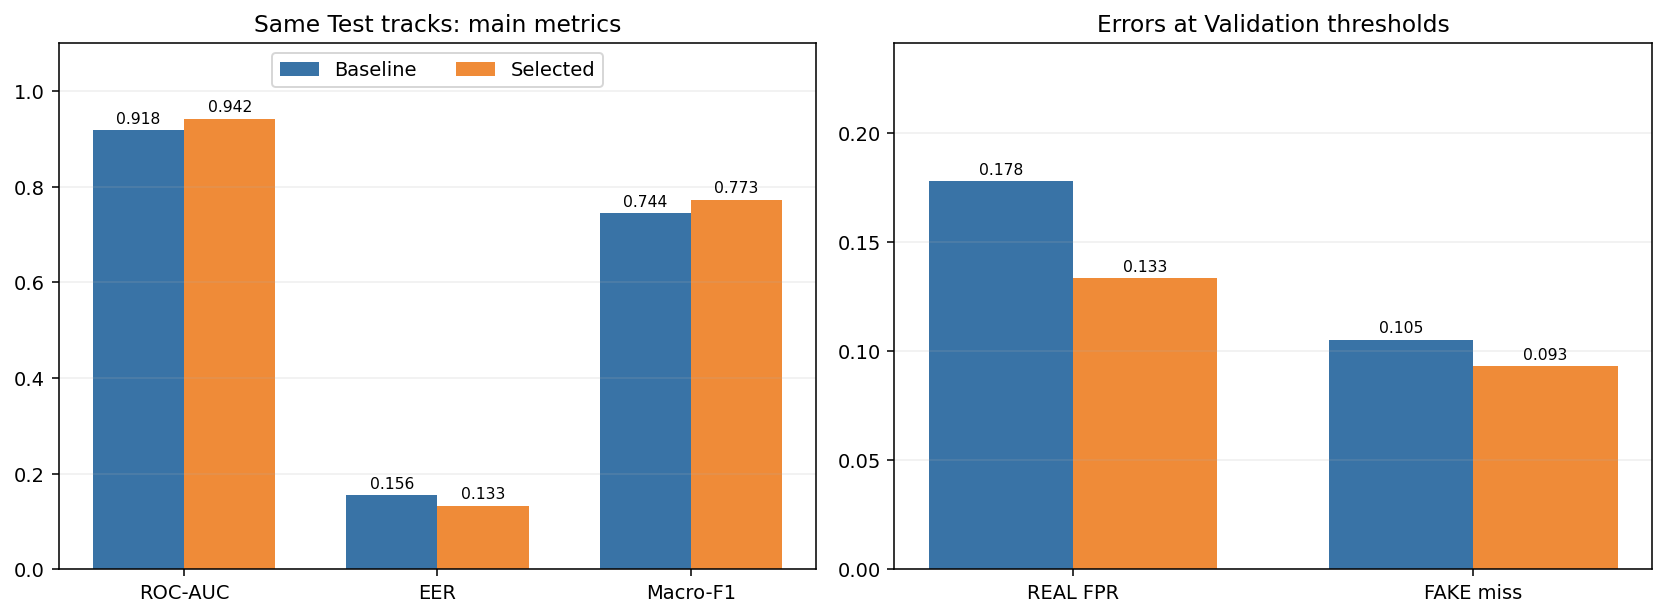

Saved: results/model_tuning/test_comparisons/logistic_test_comparison.png


In [10]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
# Validation 후보 그림과 공동 Test 그림은 폴더도 구분해 저장한다.
figure_dir = result_dir / "test_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)

# 최종 공동 Test CSV에서 이 모델의 곡 단위 두 행만 읽는다.
model_name = 'LogisticRegression'
final_results = pd.read_csv(result_dir / "optimized_test_results.csv")
rows = final_results.loc[
    (final_results["model"] == model_name)
    & (final_results["split"] == "test")
    & (final_results["level"] == "track")
].copy()
assert len(rows) == 2 and set(rows["variant"]) == {"baseline", "optimized"}
expected_run_id = json.loads((result_dir / "classical_best_configs.json").read_text())["run_id"]
assert rows["run_id"].nunique() == 1 and rows["run_id"].iloc[0] == expected_run_id
assert rows["n"].eq(539).all() and rows["n_real"].eq(45).all() and rows["n_fake"].eq(494).all()
baseline = rows.set_index("variant").loc["baseline"]
selected = rows.set_index("variant").loc["optimized"]

# EER과 AUC는 Test 점수에서 계산됐다. 분류 오류율에는 각 설정의 Validation 임계값을 썼다.
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "Validation threshold": [baseline["threshold"], selected["threshold"]],
    "ROC-AUC ↑": [baseline["roc_auc"], selected["roc_auc"]],
    "EER ↓": [baseline["eer"], selected["eer"]],
    "Macro-F1 ↑": [baseline["macro_f1"], selected["macro_f1"]],
    "REAL FPR ↓": [baseline["real_fpr"], selected["real_fpr"]],
    "FAKE miss ↓": [baseline["fake_miss_rate"], selected["fake_miss_rate"]],
})
display(summary.round(4))

# 왼쪽은 앞의 Validation 비교와 같은 세 지표, 오른쪽은 오류 방향을 보여 준다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
main_metrics = [("ROC-AUC", "roc_auc"), ("EER", "eer"), ("Macro-F1", "macro_f1")]
error_metrics = [("REAL FPR", "real_fpr"), ("FAKE miss", "fake_miss_rate")]
for ax, metrics, title in [
    (axes[0], main_metrics, "Same Test tracks: main metrics"),
    (axes[1], error_metrics, "Errors at Validation thresholds"),
]:
    positions = np.arange(len(metrics))
    baseline_values = [baseline[column] for _, column in metrics]
    selected_values = [selected[column] for _, column in metrics]
    baseline_bars = ax.bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
    selected_bars = ax.bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
    ax.bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_xticks(positions, [label for label, _ in metrics])
    ax.set_ylim(0, 1.10 if ax is axes[0] else max(baseline_values + selected_values) * 1.3 + 0.01)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper center", ncol=2)
fig.tight_layout()
figure_path = figure_dir / 'logistic_test_comparison.png'
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))


## 11. RBF-SVM — 저장된 공동 Test 비교

저장된 공동 Test 결과의 같은 539곡을 비교한다. AUC·EER은 Test 점수에서 계산했고, Macro-F1·REAL FPR·FAKE miss에는 각 설정의 Validation 임계값을 적용했다. 여기서는 모델이나 임계값을 다시 선택하지 않는다.

설정,Validation threshold,ROC-AUC ↑,EER ↓,Macro-F1 ↑,REAL FPR ↓,FAKE miss ↓
Baseline,0.5926,0.9717,0.0889,0.8185,0.0889,0.0709
Selected,0.6615,0.9586,0.1255,0.8470,0.1556,0.0445


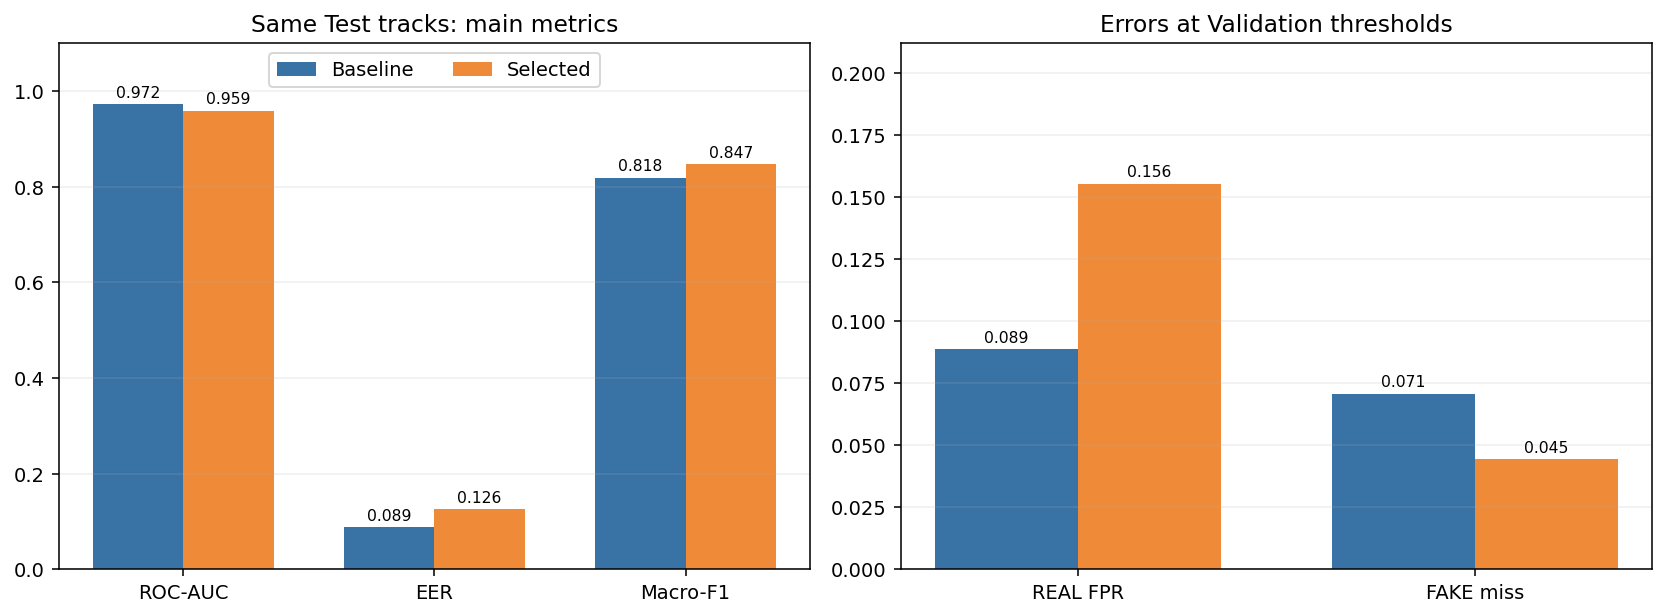

Saved: results/model_tuning/test_comparisons/svm_test_comparison.png


In [11]:
# 저장된 후보 결과만 읽는다. 이 셀은 모델을 다시 학습하거나 Test를 열지 않는다.
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "results" / "model_tuning").is_dir():
    project_root = project_root.parent
result_dir = project_root / "results" / "model_tuning"
assert result_dir.is_dir(), "프로젝트 루트 또는 archive_notebooks에서 실행하세요."
figure_dir = result_dir / "validation_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)
# Validation 후보 그림과 공동 Test 그림은 폴더도 구분해 저장한다.
figure_dir = result_dir / "test_comparisons"
figure_dir.mkdir(parents=True, exist_ok=True)

# 최종 공동 Test CSV에서 이 모델의 곡 단위 두 행만 읽는다.
model_name = 'RBF-SVM'
final_results = pd.read_csv(result_dir / "optimized_test_results.csv")
rows = final_results.loc[
    (final_results["model"] == model_name)
    & (final_results["split"] == "test")
    & (final_results["level"] == "track")
].copy()
assert len(rows) == 2 and set(rows["variant"]) == {"baseline", "optimized"}
expected_run_id = json.loads((result_dir / "classical_best_configs.json").read_text())["run_id"]
assert rows["run_id"].nunique() == 1 and rows["run_id"].iloc[0] == expected_run_id
assert rows["n"].eq(539).all() and rows["n_real"].eq(45).all() and rows["n_fake"].eq(494).all()
baseline = rows.set_index("variant").loc["baseline"]
selected = rows.set_index("variant").loc["optimized"]

# EER과 AUC는 Test 점수에서 계산됐다. 분류 오류율에는 각 설정의 Validation 임계값을 썼다.
summary = pd.DataFrame({
    "설정": ["Baseline", "Selected"],
    "Validation threshold": [baseline["threshold"], selected["threshold"]],
    "ROC-AUC ↑": [baseline["roc_auc"], selected["roc_auc"]],
    "EER ↓": [baseline["eer"], selected["eer"]],
    "Macro-F1 ↑": [baseline["macro_f1"], selected["macro_f1"]],
    "REAL FPR ↓": [baseline["real_fpr"], selected["real_fpr"]],
    "FAKE miss ↓": [baseline["fake_miss_rate"], selected["fake_miss_rate"]],
})
display(summary.round(4))

# 왼쪽은 앞의 Validation 비교와 같은 세 지표, 오른쪽은 오류 방향을 보여 준다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
main_metrics = [("ROC-AUC", "roc_auc"), ("EER", "eer"), ("Macro-F1", "macro_f1")]
error_metrics = [("REAL FPR", "real_fpr"), ("FAKE miss", "fake_miss_rate")]
for ax, metrics, title in [
    (axes[0], main_metrics, "Same Test tracks: main metrics"),
    (axes[1], error_metrics, "Errors at Validation thresholds"),
]:
    positions = np.arange(len(metrics))
    baseline_values = [baseline[column] for _, column in metrics]
    selected_values = [selected[column] for _, column in metrics]
    baseline_bars = ax.bar(positions - 0.18, baseline_values, 0.36, label="Baseline", color="#3973a6")
    selected_bars = ax.bar(positions + 0.18, selected_values, 0.36, label="Selected", color="#ef8b38")
    ax.bar_label(baseline_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(selected_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_xticks(positions, [label for label, _ in metrics])
    ax.set_ylim(0, 1.10 if ax is axes[0] else max(baseline_values + selected_values) * 1.3 + 0.01)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper center", ncol=2)
fig.tight_layout()
figure_path = figure_dir / 'svm_test_comparison.png'
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(project_root))
